# n_bytes Distribution Analysis


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, probplot
from utils import load_dataset

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

In [2]:
data_inst   = load_dataset("institutions")
data_subnet = load_dataset("subnets")
data_ips    = load_dataset("ips")

100%|████████████████████████| 283/283 [00:07<00:00, 36.94it/s]


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.INSTITUTIONS

    Time series
        Time series IDS: [ 19 150 193 148 153 ...  81 214 159  46 124], Length=283
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
 

institutions (AGG_1_HOUR): 283 series loaded


100%|████████████████████████| 548/548 [00:07<00:00, 70.77it/s]


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.INSTITUTION_SUBNETS

    Time series
        Time series IDS: [ 36 362  30 453  76 ... 455 236 350 432 209], Length=548
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch siz

subnets (AGG_1_HOUR): 548 series loaded


100%|█████████████████████| 1000/1000 [00:07<00:00, 129.38it/s]


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.IP_ADDRESSES_SAMPLE

    Time series
        Time series IDS: [  50506    7516 1573838   98094  629496 ...  395962 1925686 1890333  151800 1673776], Length=1000
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        T

ips (AGG_1_HOUR): 1000 series loaded


In [3]:
levels = {
    "Institutions (283)": (data_inst["df"], data_inst["id_col"]),
    "Subnets (548)":       (data_subnet["df"], data_subnet["id_col"]),
    "IPs Sample (1000)":   (data_ips["df"], data_ips["id_col"]),
}

## Per-series statistics

In [4]:
def per_series_stats(df, id_col, feature="n_bytes", transform=None):
    rows = []
    for ts_id, grp in df.groupby(id_col, sort=False):
        y = grp[feature].dropna().astype(float).values
        if y.size == 0:
            continue
        if transform is not None:
            y = transform(y)
        mean, median, std = y.mean(), float(np.median(y)), y.std()
        ymin, ymax = float(y.min()), float(y.max())
        rows.append({
            id_col: ts_id,
            "mean": mean,
            "median": median,
            "std": std,
            "min": ymin,
            "max": ymax,
            "range": ymax - ymin,
            "skewness": float(skew(y)),
            "kurtosis": float(kurtosis(y)),
            "cv": std / mean if mean > 0 else np.nan,
            "mean_median_ratio": mean / median if median > 0 else np.nan,
            "max_median_ratio": ymax / median if median > 0 else np.nan,
        })
    return pd.DataFrame(rows)

stats_raw = {name: per_series_stats(df, col) for name, (df, col) in levels.items()}
stats_log = {name: per_series_stats(df, col, transform=np.log1p) for name, (df, col) in levels.items()}

for name, s in stats_raw.items():
    print(f"{name}: {len(s)} series")

Institutions (283): 283 series
Subnets (548): 548 series
IPs Sample (1000): 1000 series


### Summary table

In [5]:
summary_rows = []
for name in levels:
    for tag, stats_d in [("raw", stats_raw), ("log1p", stats_log)]:
        s = stats_d[name]
        summary_rows.append({
            "level": name,
            "transform": tag,
            "skew":            s["skewness"].median(),
            "kurtosis":        s["kurtosis"].median(),
            "mean/median":     s["mean_median_ratio"].median(),
            "cv":              s["cv"].median(),
            "max/median":      s["max_median_ratio"].median(),
        })
summary = pd.DataFrame(summary_rows).set_index(["level", "transform"])
summary.round(3)

skew  kurtosis  mean/median      cv  \
level              transform                                          
Institutions (283) raw         4.864    45.200        2.490   1.681   
                   log1p      -0.689     5.130        0.999   0.085   
Subnets (548)      raw         6.279    78.475        2.341   1.899   
                   log1p      -0.659     5.733        0.997   0.102   
IPs Sample (1000)  raw        27.968   987.605        3.862  13.865   
                   log1p       3.442    15.849        0.950   3.594   

                              max/median  
level              transform              
Institutions (283) raw            93.567  
                   log1p           1.254  
Subnets (548)      raw           124.917  
                   log1p           1.306  
IPs Sample (1000)  raw          1111.568  
                   log1p           1.665

## Distributions across series (raw)

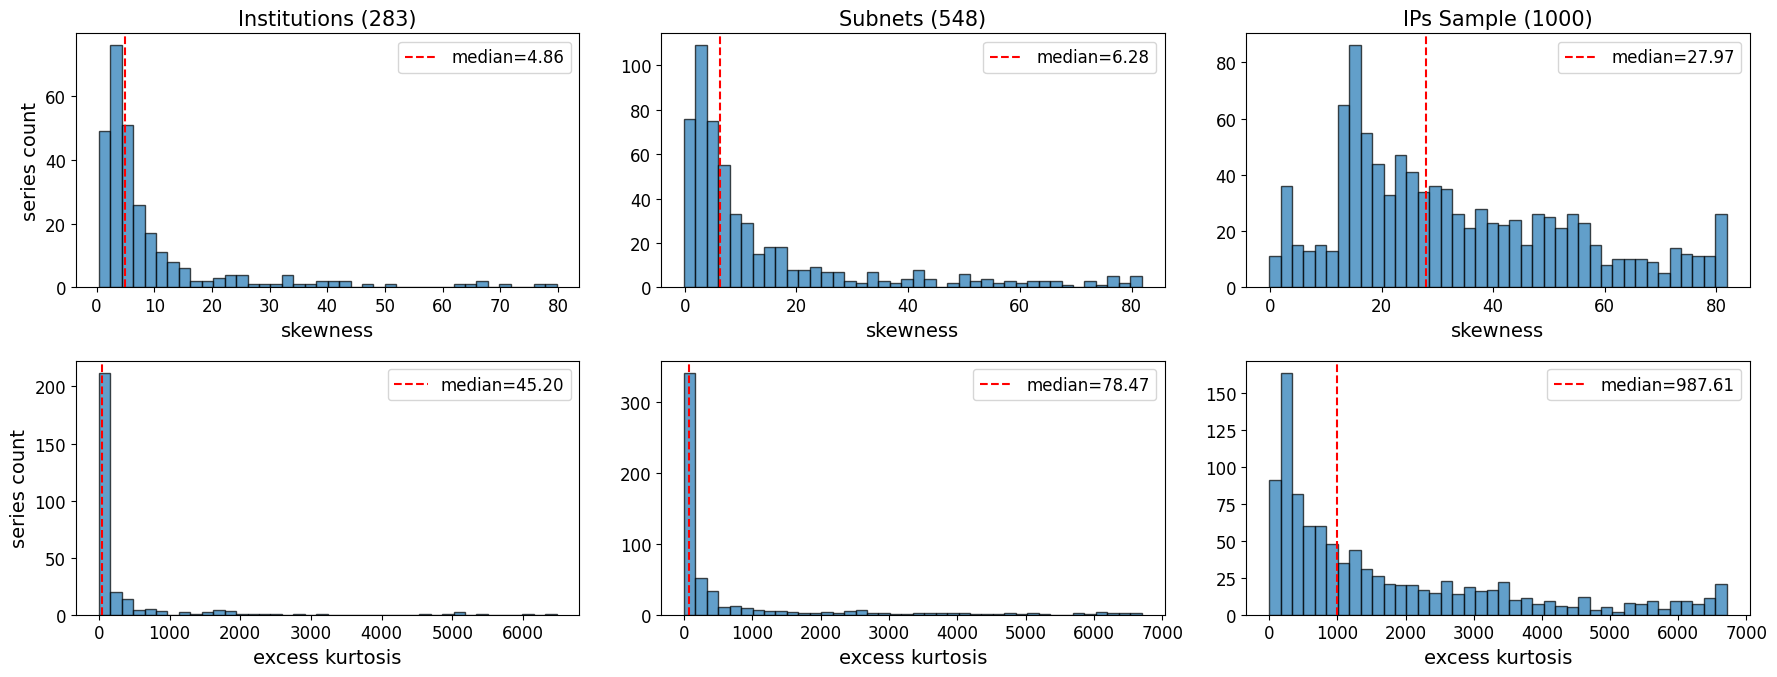

In [6]:
stat_cols = [
    ("skewness",          "skewness",            False),
    ("kurtosis",          "excess kurtosis",     False),
    # ("mean_median_ratio", "mean / median",        False),
    # ("cv",                "CV = std / mean",     False),
    # ("max_median_ratio",  "max / median",         True),
]

level_names = list(levels.keys())
fig, axes = plt.subplots(len(stat_cols), len(level_names),
                         figsize=(6 * len(level_names), 3.5 * len(stat_cols)))

for row, (col, xlabel, use_log) in enumerate(stat_cols):
    for j, name in enumerate(level_names):
        ax = axes[row, j]
        vals = stats_raw[name][col].dropna().values
        if use_log:
            pos = vals[vals > 0]
            ax.hist(pos, bins=np.logspace(np.log10(pos.min()), np.log10(pos.max()), 40),
                    edgecolor="black", alpha=0.7)
            ax.set_xscale("log")
        else:
            ax.hist(vals, bins=40, edgecolor="black", alpha=0.7)
        med = np.median(vals)
        ax.axvline(med, color="red", linestyle="--", label=f"median={med:.2f}")
        if row == 0:
            ax.set_title(name)
        ax.set_xlabel(xlabel)
        if j == 0:
            ax.set_ylabel("series count")
        ax.legend()

# plt.suptitle("Within-series statistics across series (raw n_bytes)", y=1.002)
plt.tight_layout()
plt.show()
# fig.savefig('nbytes_per_series_raw.pdf', bbox_inches='tight')

## Raw vs log1p

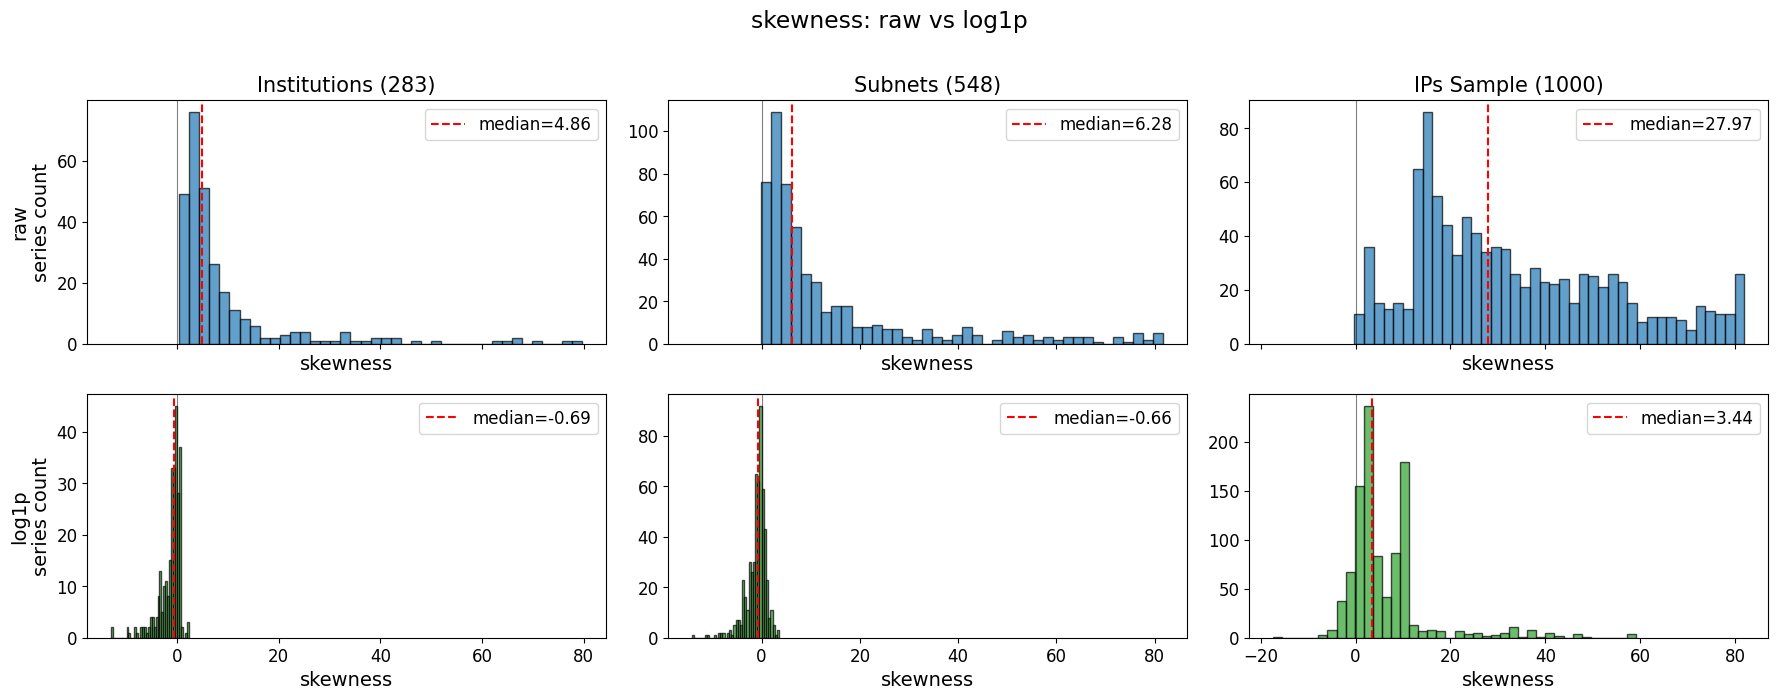

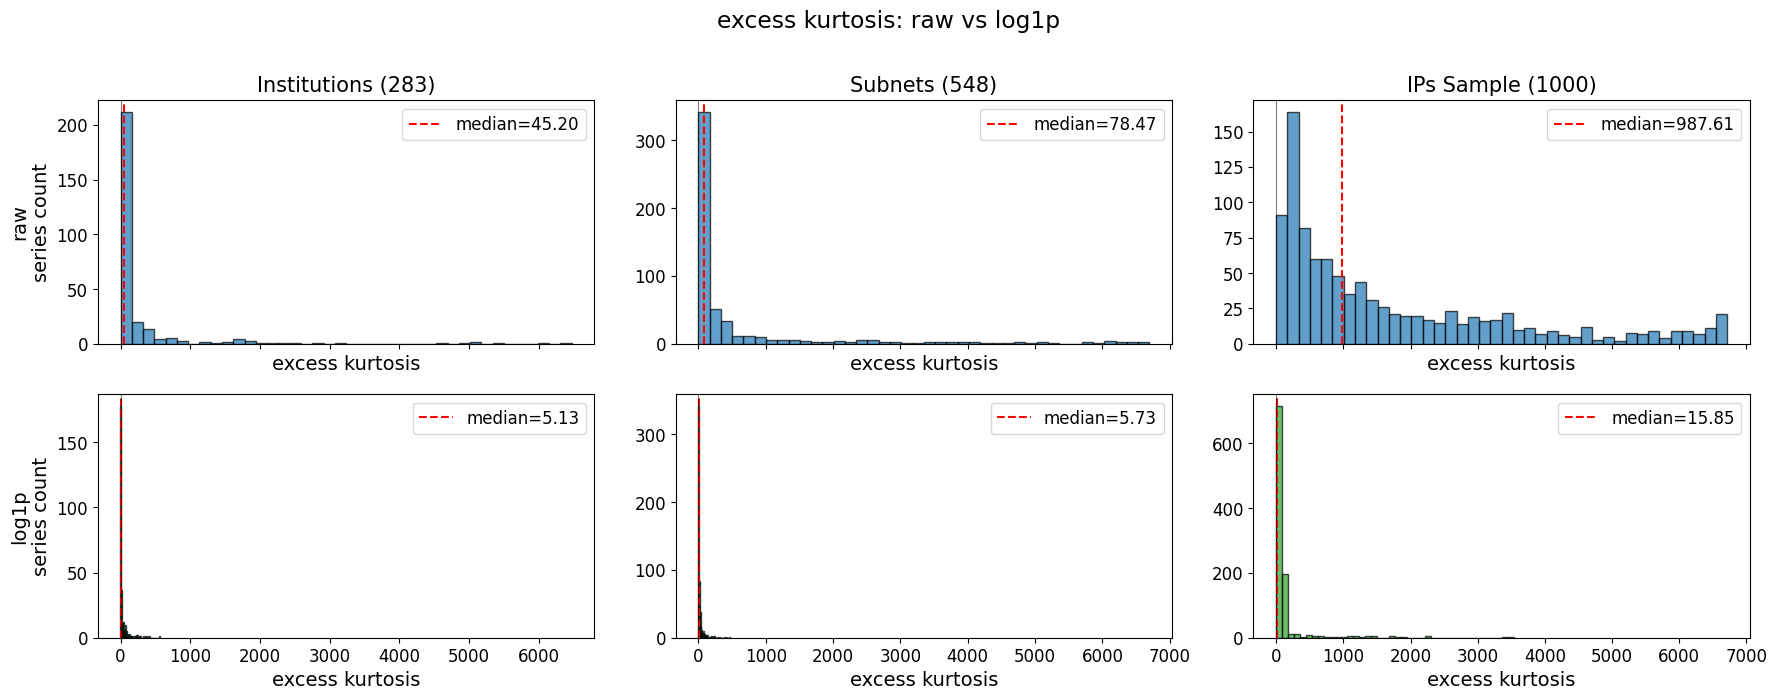

In [7]:
def _plot_before_after(stat_col, xlabel):
    fig, axes = plt.subplots(2, len(level_names), figsize=(6 * len(level_names), 7),
                             sharex='col')
    for j, name in enumerate(level_names):
        for i, (tag, store) in enumerate([("raw", stats_raw), ("log1p", stats_log)]):
            ax = axes[i, j]
            vals = store[name][stat_col].dropna().values
            ax.hist(vals, bins=40, edgecolor="black", alpha=0.7,
                    color="C0" if tag == "raw" else "C2")
            med = np.median(vals)
            ax.axvline(med, color="red", linestyle="--", label=f"median={med:.2f}")
            ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
            if i == 0:
                ax.set_title(name)
            if j == 0:
                ax.set_ylabel(f"{tag}\nseries count")
            ax.set_xlabel(xlabel)
            ax.legend()
    plt.suptitle(f"{xlabel}: raw vs log1p", y=1.002)
    plt.tight_layout()
    plt.show()
    return fig

fig_skew = _plot_before_after("skewness", "skewness")
fig_kurt = _plot_before_after("kurtosis", "excess kurtosis")
# fig_skew.savefig('nbytes_skew_raw_vs_log1p.pdf', bbox_inches='tight')
# fig_kurt.savefig('nbytes_kurt_raw_vs_log1p.pdf', bbox_inches='tight')

## Example series

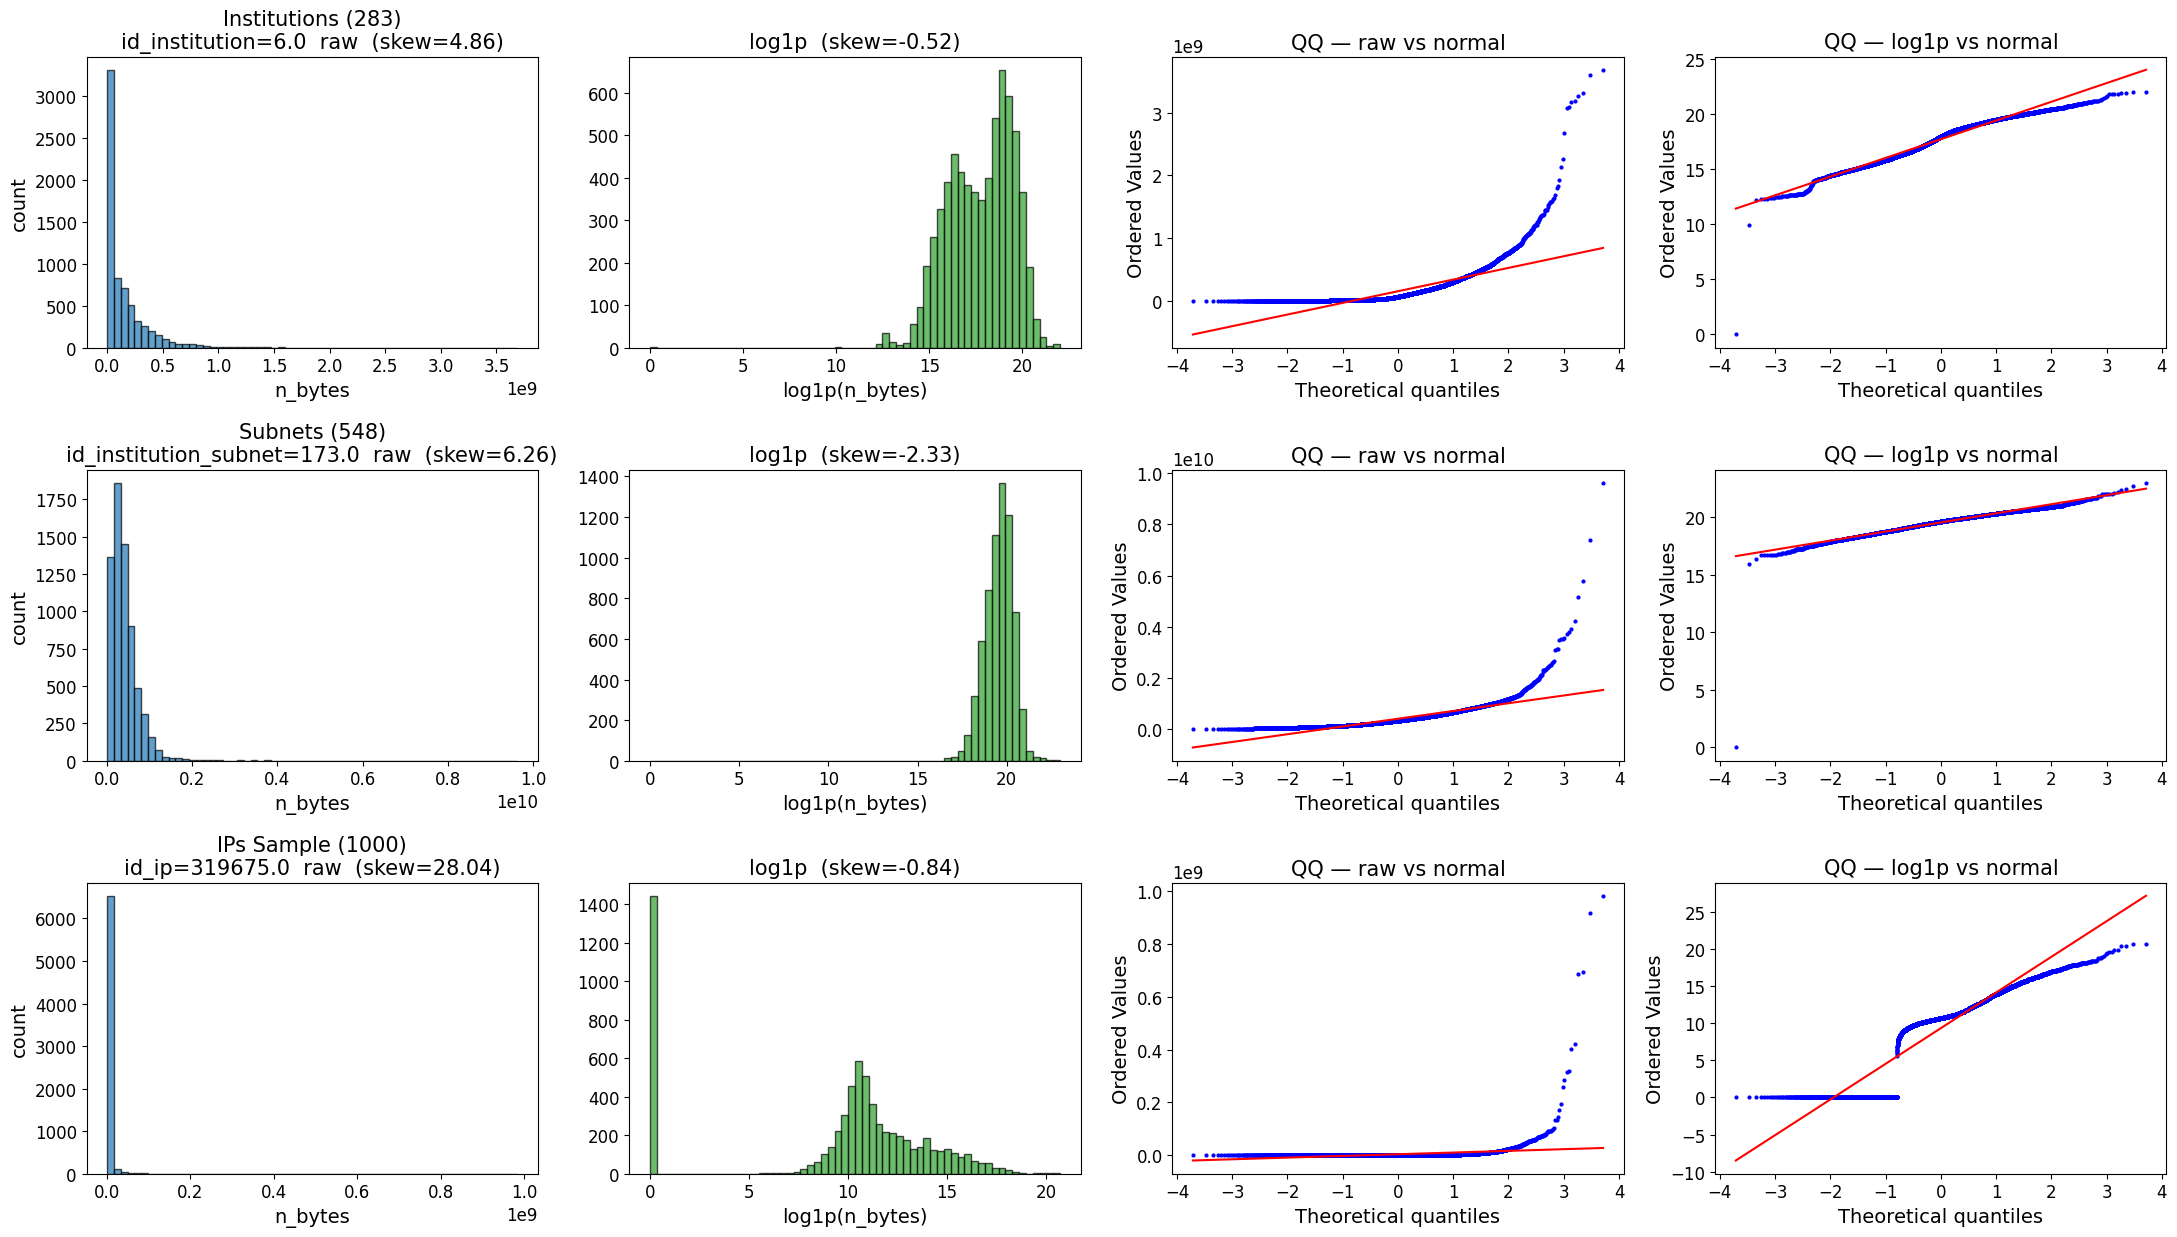

In [8]:
def _pick_median_skew(stats_df, id_col):
    med = stats_df["skewness"].median()
    idx = (stats_df["skewness"] - med).abs().idxmin()
    row = stats_df.loc[idx]
    return row[id_col], float(row["skewness"])

fig, axes = plt.subplots(len(level_names), 4, figsize=(22, 4.2 * len(level_names)))

for i, name in enumerate(level_names):
    df, id_col = levels[name]
    ts_id, sk_raw = _pick_median_skew(stats_raw[name], id_col)
    y = df[df[id_col] == ts_id]["n_bytes"].dropna().astype(float).values
    y_log = np.log1p(y)
    sk_log = float(skew(y_log))

    axes[i, 0].hist(y, bins=60, edgecolor="black", alpha=0.7)
    axes[i, 0].set_title(f"{name}\n{id_col}={ts_id}  raw  (skew={sk_raw:.2f})")
    axes[i, 0].set_xlabel("n_bytes")
    axes[i, 0].set_ylabel("count")

    axes[i, 1].hist(y_log, bins=60, edgecolor="black", alpha=0.7, color="C2")
    axes[i, 1].set_title(f"log1p  (skew={sk_log:.2f})")
    axes[i, 1].set_xlabel("log1p(n_bytes)")

    probplot(y, dist="norm", plot=axes[i, 2])
    axes[i, 2].get_lines()[0].set_markersize(2)
    axes[i, 2].set_title("QQ — raw vs normal")
    probplot(y_log, dist="norm", plot=axes[i, 3])
    axes[i, 3].get_lines()[0].set_markersize(2)
    axes[i, 3].set_title("QQ — log1p vs normal")

plt.tight_layout()
plt.show()
# fig.savefig('nbytes_example_series.pdf', bbox_inches='tight')

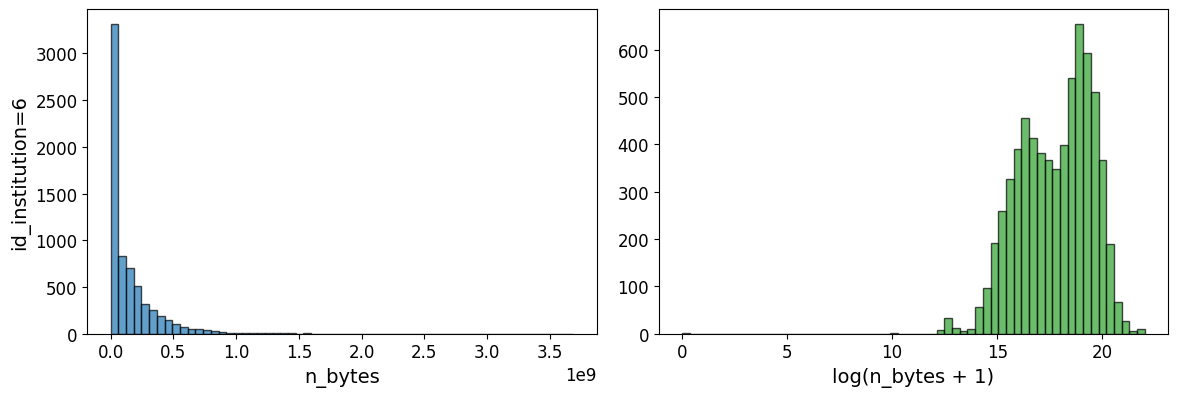

In [9]:
name = "Institutions (283)"
df, id_col = levels[name]
ts_id, _ = _pick_median_skew(stats_raw[name], id_col)
y = df[df[id_col] == ts_id]["n_bytes"].dropna().astype(float).values
y_log = np.log1p(y)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, data, xlabel, color in [
    (axes[0], y,     "n_bytes",        "C0"),
    (axes[1], y_log, "log(n_bytes + 1)", "C2"),
]:
    ax.hist(data, bins=60, edgecolor="black", alpha=0.7, color=color)
    ax.set_xlabel(xlabel)

axes[0].set_ylabel(f"{id_col}={int(ts_id)}")

plt.tight_layout()
plt.show()
# fig.savefig('exploration/figures/nbytes_raw_vs_log1p_institution.pdf', bbox_inches='tight')

## Typical scale per aggregation level

In [10]:
for name, (df, id_col) in levels.items():
    per_series_means = df.groupby(id_col)["n_bytes"].apply(
        lambda y: y.dropna().astype(float).pipe(lambda s: s[s > 0].mean())
    ).dropna()
    print(f"{name}:")
    print(f"  Median of per-series means: {per_series_means.median():.0f}")
    print(f"  Q25: {per_series_means.quantile(0.25):.0f}")
    print(f"  Q75: {per_series_means.quantile(0.75):.0f}")
    print()

Institutions (283):
  Median of per-series means: 230072466
  Q25: 80917864
  Q75: 649325549

Subnets (548):
  Median of per-series means: 78879796
  Q25: 682933
  Q75: 376423938

IPs Sample (1000):
  Median of per-series means: 756876
  Q25: 1665
  Q75: 4149655



# 10-Minute Resolution

In [ ]:
from cesnet_tszoo.utils.enums import AgreggationType
from config import AGGREGATIONS

agg_10min = AGGREGATIONS["10min"]

data_inst_10   = load_dataset("institutions", aggregation=agg_10min["enum"], time_range=agg_10min["time_range"])
data_subnet_10 = load_dataset("subnets",      aggregation=agg_10min["enum"], time_range=agg_10min["time_range"])
data_ips_10    = load_dataset("ips",           aggregation=agg_10min["enum"], time_range=agg_10min["time_range"])

In [ ]:
levels_10 = {
    "Institutions (283)": (data_inst_10["df"], data_inst_10["id_col"]),
    "Subnets (548)":       (data_subnet_10["df"], data_subnet_10["id_col"]),
    "IPs Sample (1000)":   (data_ips_10["df"], data_ips_10["id_col"]),
}

## Per-series statistics

In [ ]:
stats_raw_10 = {name: per_series_stats(df, col) for name, (df, col) in levels_10.items()}
stats_log_10 = {name: per_series_stats(df, col, transform=np.log1p) for name, (df, col) in levels_10.items()}

for name, s in stats_raw_10.items():
    print(f"{name}: {len(s)} series")

Institutions (283): 283 series
Subnets (548): 548 series
IPs Sample (1000): 1000 series


### Summary table

In [ ]:
summary_rows_10 = []
for name in levels_10:
    for tag, stats_d in [("raw", stats_raw_10), ("log1p", stats_log_10)]:
        s = stats_d[name]
        summary_rows_10.append({
            "level": name,
            "transform": tag,
            "skew":            s["skewness"].median(),
            "kurtosis":        s["kurtosis"].median(),
            "mean/median":     s["mean_median_ratio"].median(),
            "cv":              s["cv"].median(),
            "max/median":      s["max_median_ratio"].median(),
        })
summary_10 = pd.DataFrame(summary_rows_10).set_index(["level", "transform"])
summary_10.round(3)

skew  kurtosis  mean/median      cv  \
level              transform                                          
Institutions (283) raw        14.958   429.468        4.329   2.722   
                   log1p      -0.383     1.479        0.998   0.131   
Subnets (548)      raw        19.449   710.485        4.367   3.169   
                   log1p      -0.394     1.946        0.995   0.161   
IPs Sample (1000)  raw        58.587  4447.982        3.988  25.667   
                   log1p       4.372    19.225        0.876   4.297   

                              max/median  
level              transform              
Institutions (283) raw           766.505  
                   log1p           1.432  
Subnets (548)      raw          1041.237  
                   log1p           1.517  
IPs Sample (1000)  raw          3483.810  
                   log1p           2.074

## Distributions across series (raw)

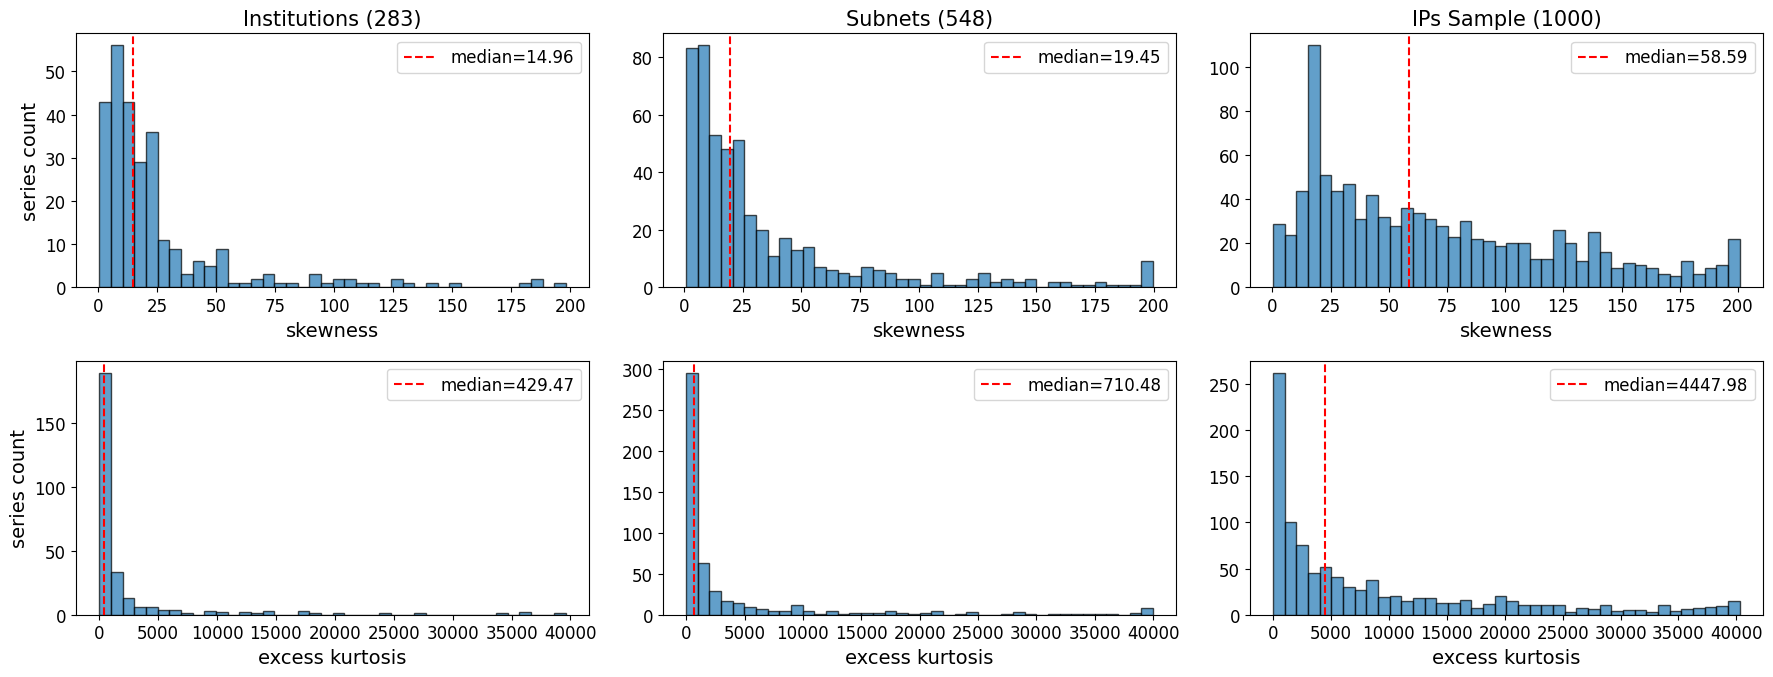

In [ ]:
level_names_10 = list(levels_10.keys())
fig, axes = plt.subplots(len(stat_cols), len(level_names_10),
                         figsize=(6 * len(level_names_10), 3.5 * len(stat_cols)))

for row, (col, xlabel, use_log) in enumerate(stat_cols):
    for j, name in enumerate(level_names_10):
        ax = axes[row, j] if len(stat_cols) > 1 else axes[j]
        vals = stats_raw_10[name][col].dropna().values
        if use_log:
            pos = vals[vals > 0]
            ax.hist(pos, bins=np.logspace(np.log10(pos.min()), np.log10(pos.max()), 40),
                    edgecolor="black", alpha=0.7)
            ax.set_xscale("log")
        else:
            ax.hist(vals, bins=40, edgecolor="black", alpha=0.7)
        med = np.median(vals)
        ax.axvline(med, color="red", linestyle="--", label=f"median={med:.2f}")
        if row == 0:
            ax.set_title(name)
        ax.set_xlabel(xlabel)
        if j == 0:
            ax.set_ylabel("series count")
        ax.legend()

plt.tight_layout()
plt.show()

## Raw vs log1p

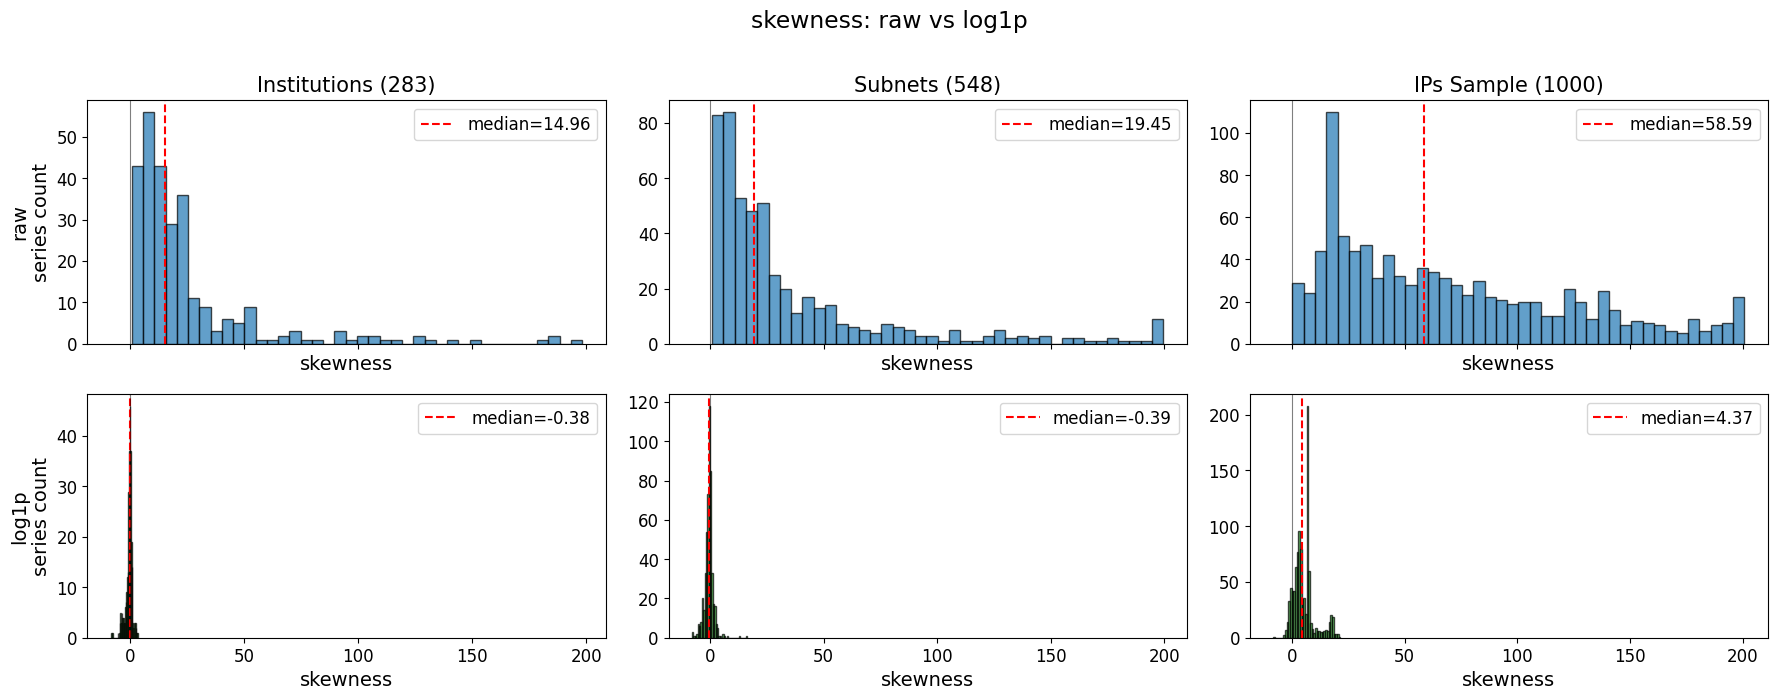

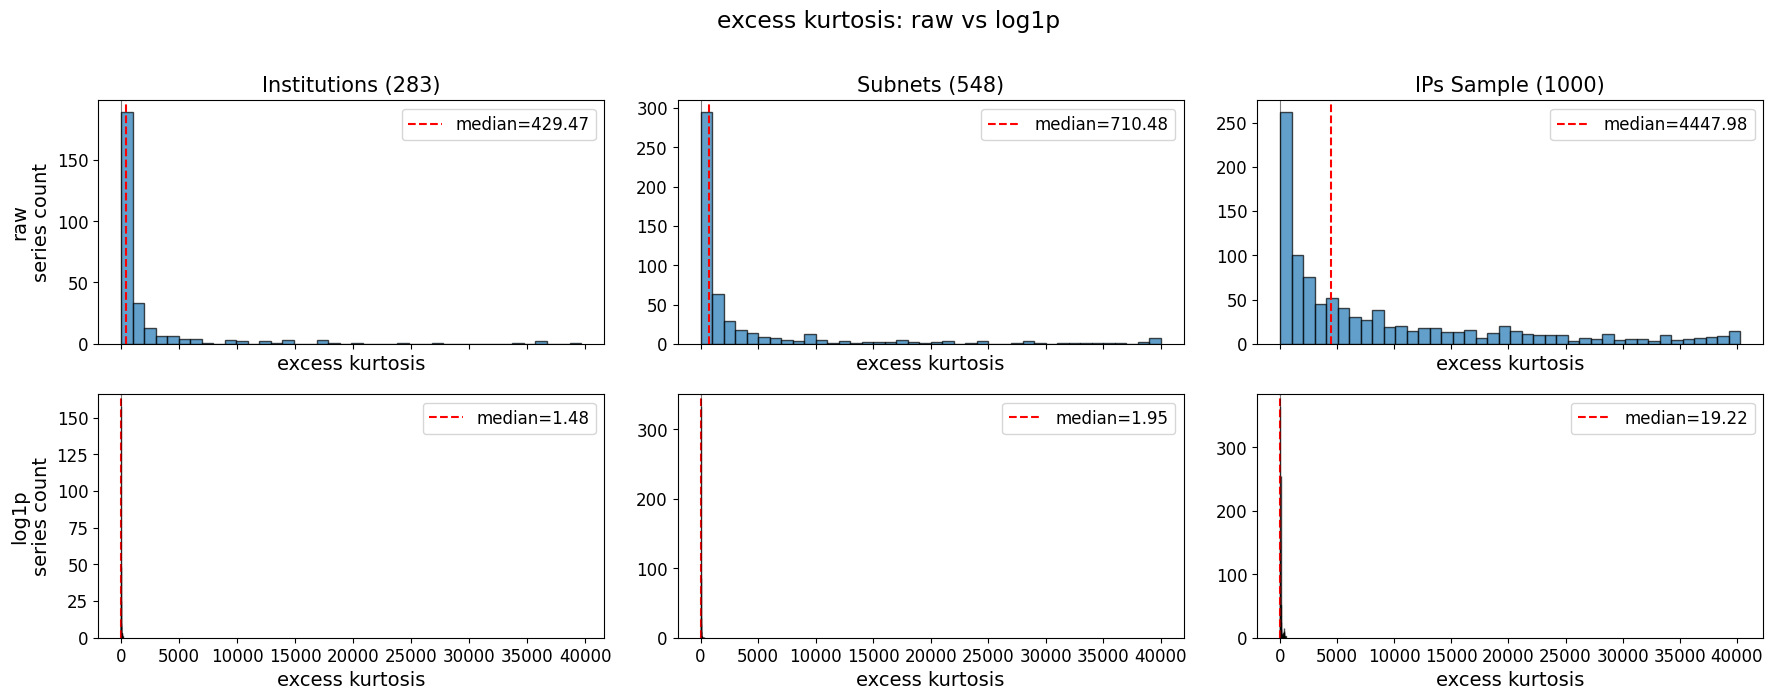

In [ ]:
def _plot_before_after_10(stat_col, xlabel):
    fig, axes = plt.subplots(2, len(level_names_10), figsize=(6 * len(level_names_10), 7),
                             sharex='col')
    for j, name in enumerate(level_names_10):
        for i, (tag, store) in enumerate([("raw", stats_raw_10), ("log1p", stats_log_10)]):
            ax = axes[i, j]
            vals = store[name][stat_col].dropna().values
            ax.hist(vals, bins=40, edgecolor="black", alpha=0.7,
                    color="C0" if tag == "raw" else "C2")
            med = np.median(vals)
            ax.axvline(med, color="red", linestyle="--", label=f"median={med:.2f}")
            ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
            if i == 0:
                ax.set_title(name)
            if j == 0:
                ax.set_ylabel(f"{tag}\nseries count")
            ax.set_xlabel(xlabel)
            ax.legend()
    plt.suptitle(f"{xlabel}: raw vs log1p", y=1.002)
    plt.tight_layout()
    plt.show()
    return fig

fig_skew_10 = _plot_before_after_10("skewness", "skewness")
fig_kurt_10 = _plot_before_after_10("kurtosis", "excess kurtosis")

## Example series

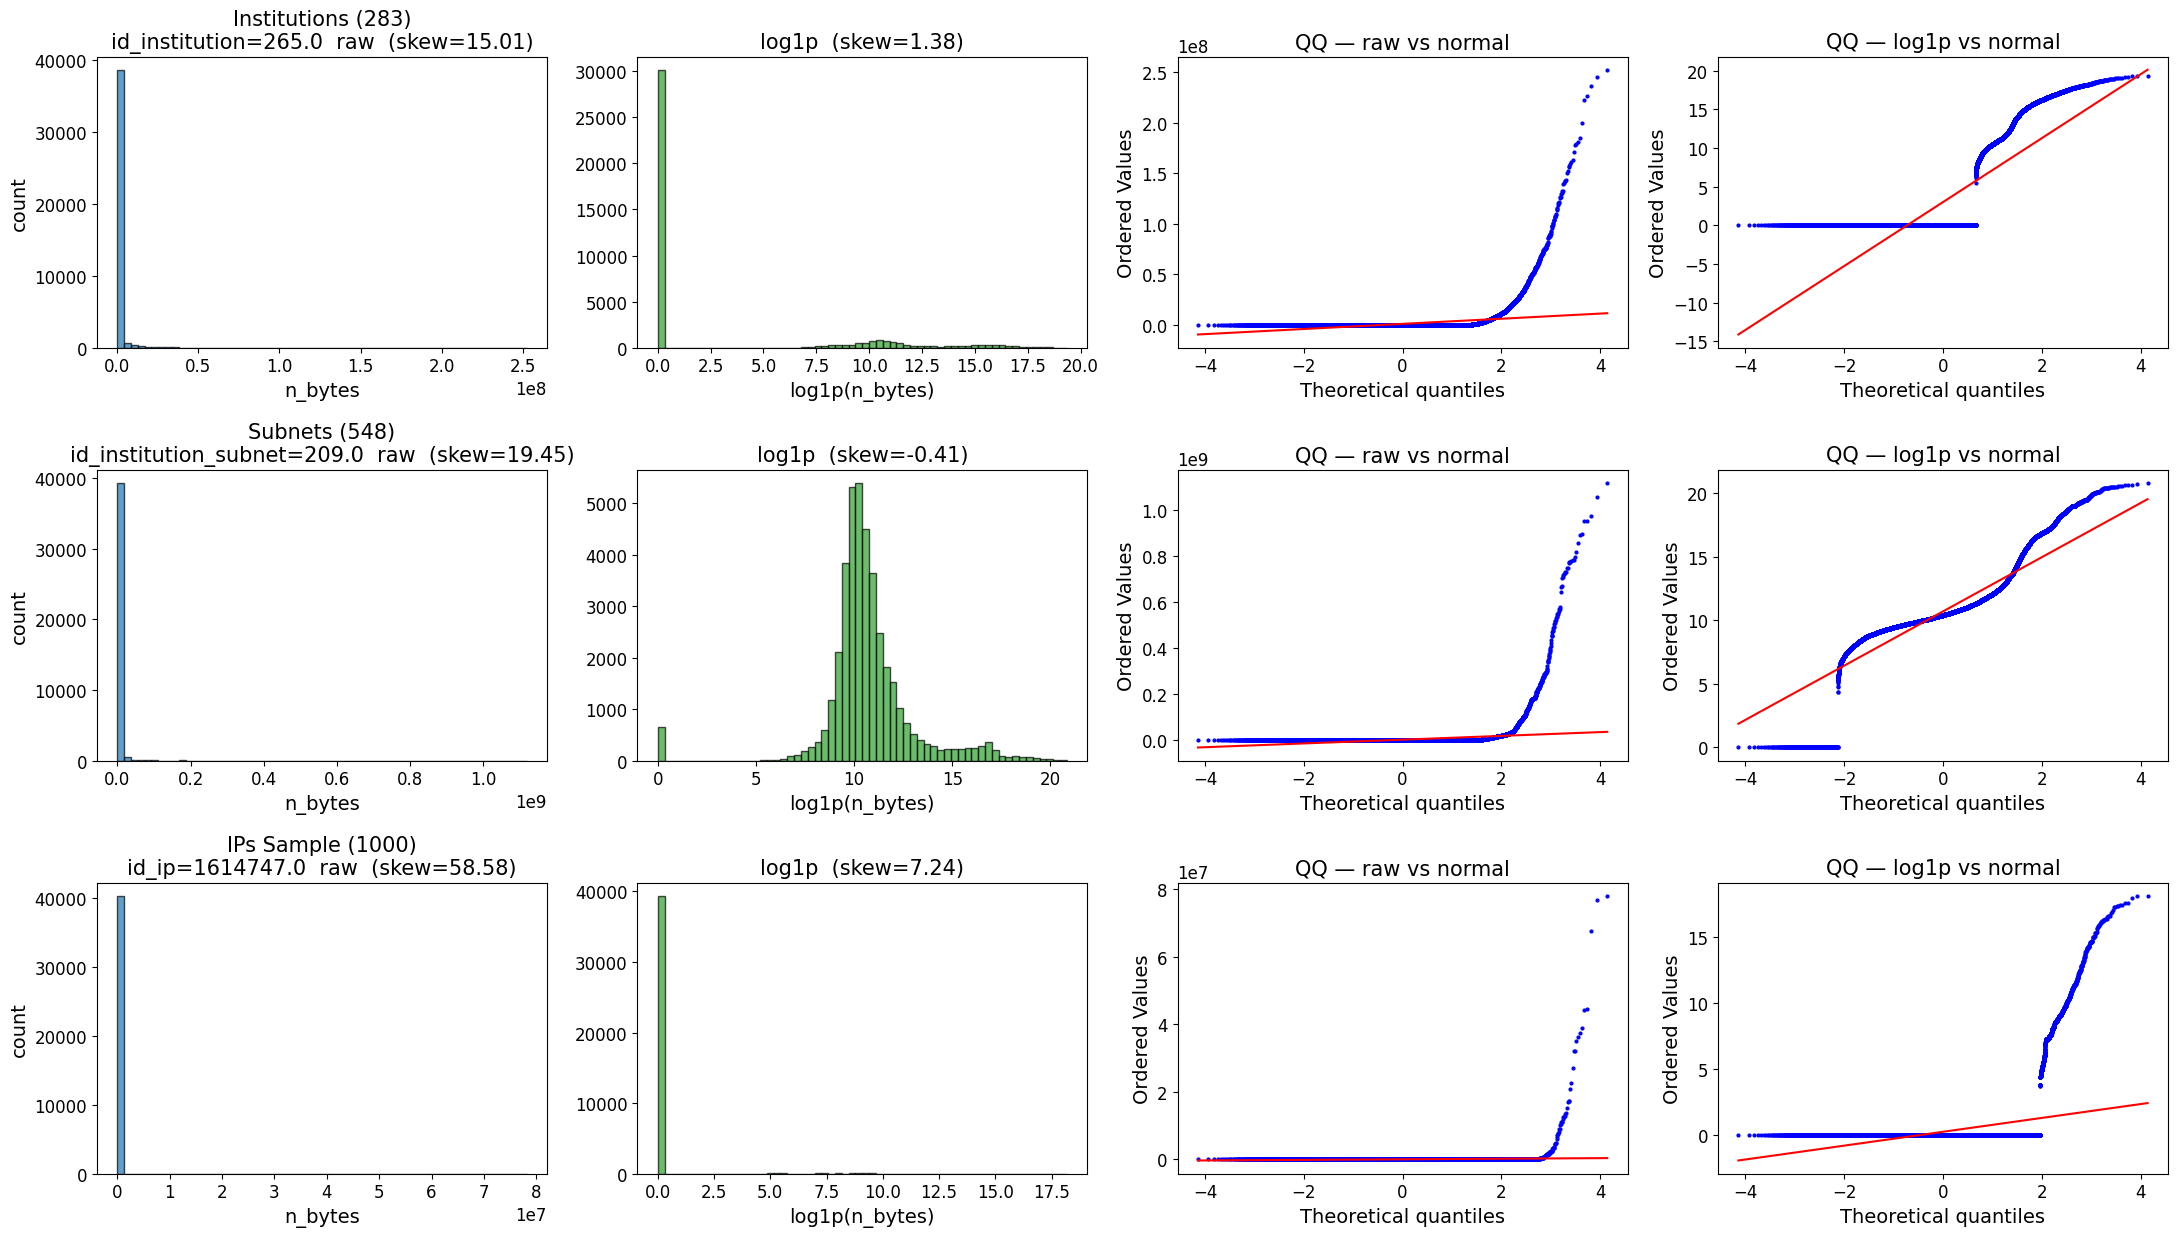

In [ ]:
fig, axes = plt.subplots(len(level_names_10), 4, figsize=(22, 4.2 * len(level_names_10)))

for i, name in enumerate(level_names_10):
    df, id_col = levels_10[name]
    ts_id, sk_raw = _pick_median_skew(stats_raw_10[name], id_col)
    y = df[df[id_col] == ts_id]["n_bytes"].dropna().astype(float).values
    y_log = np.log1p(y)
    sk_log = float(skew(y_log))

    axes[i, 0].hist(y, bins=60, edgecolor="black", alpha=0.7)
    axes[i, 0].set_title(f"{name}\n{id_col}={ts_id}  raw  (skew={sk_raw:.2f})")
    axes[i, 0].set_xlabel("n_bytes")
    axes[i, 0].set_ylabel("count")

    axes[i, 1].hist(y_log, bins=60, edgecolor="black", alpha=0.7, color="C2")
    axes[i, 1].set_title(f"log1p  (skew={sk_log:.2f})")
    axes[i, 1].set_xlabel("log1p(n_bytes)")

    probplot(y, dist="norm", plot=axes[i, 2])
    axes[i, 2].get_lines()[0].set_markersize(2)
    axes[i, 2].set_title("QQ — raw vs normal")
    probplot(y_log, dist="norm", plot=axes[i, 3])
    axes[i, 3].get_lines()[0].set_markersize(2)
    axes[i, 3].set_title("QQ — log1p vs normal")

plt.tight_layout()
plt.show()

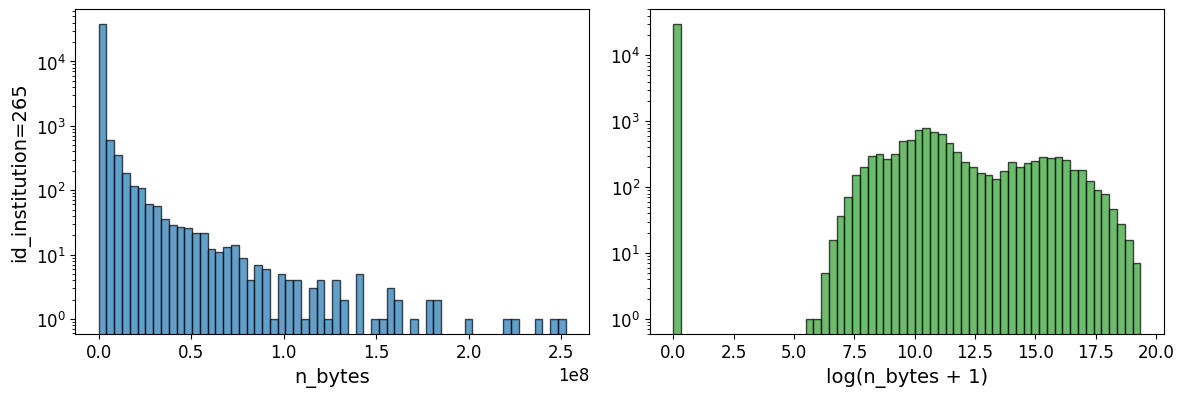

In [ ]:
name = "Institutions (283)"
df, id_col = levels_10[name]
ts_id, _ = _pick_median_skew(stats_raw_10[name], id_col)
y = df[df[id_col] == ts_id]["n_bytes"].dropna().astype(float).values
y_log = np.log1p(y)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, data, xlabel, color in [
    (axes[0], y,     "n_bytes",        "C0"),
    (axes[1], y_log, "log(n_bytes + 1)", "C2"),
]:
    ax.hist(data, bins=60, edgecolor="black", alpha=0.7, color=color)
    ax.set_xlabel(xlabel)
    ax.set_yscale("log")

axes[0].set_ylabel(f"{id_col}={int(ts_id)}")

plt.tight_layout()
plt.show()

## Typical scale per aggregation level

In [ ]:
for name, (df, id_col) in levels_10.items():
    per_series_means = df.groupby(id_col)["n_bytes"].apply(
        lambda y: y.dropna().astype(float).pipe(lambda s: s[s > 0].mean())
    ).dropna()
    print(f"{name}:")
    print(f"  Median of per-series means: {per_series_means.median():.0f}")
    print(f"  Q25: {per_series_means.quantile(0.25):.0f}")
    print(f"  Q75: {per_series_means.quantile(0.75):.0f}")
    print()

Institutions (283):
  Median of per-series means: 38986947
  Q25: 14857861
  Q75: 113867532

Subnets (548):
  Median of per-series means: 17115229
  Q25: 662438
  Q75: 71103563

IPs Sample (1000):
  Median of per-series means: 194993
  Q25: 622
  Q75: 954552

